# 06 - Results: did any of it work?

**What this step does.** Reads all 360 runs from `results/runs.jsonl` and
answers the two questions the project was built to answer.

**Why it exists.** Everything before this was apparatus. The apparatus was
worth building carefully - four separate bugs in it each produced a
confident, plausible, wrong answer - but it was never the point. This is.

The two questions, stated so they can be answered wrongly:

1. **Does a cross-domain pretrained encoder beat a random one?**
   arm A vs arm B.
2. **Does pretraining on THREE unrelated domains beat pretraining on ONE?**
   arm A vs the best arm D.

The second is the load-bearing one. A positive answer to the first with a
negative answer to the second means "pretraining helps", *not* "cross-domain
pretraining helps" - and those are very different claims.

**How a difference is judged.** Every gain is computed **per seed and then
averaged**, so the reported spread is the spread of the *difference*.
Averaging the arms first and subtracting would throw away the pairing. A gain
smaller than its own spread across seeds is labelled `indistinguishable`,
because it is not evidence of anything.

**What could go wrong.**
- **Reading a table built from a partial sweep.** It looks exactly like a
  complete one. Asserted below.
- **Comparing arm A to a weak expert.** Arm D is collapsed to its *best*
  source per cell, which is the hardest version of the comparison for arm A.
- **Pooling across domains.** Cora accuracy and Elliptic AUC-PR are not the
  same kind of number and are never averaged together.

## Setup, and checking the results are complete

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

import numpy as np
import pandas as pd

from src import config, plotting, results

plotting.use_project_style()
pd.set_option("display.width", 200)

df = results.load_frame()
cov = results.coverage(df)

print(f"runs logged        : {cov['rows']} of {cov['expected']}")
print(f"unique run ids     : {cov['unique_runs']}   (duplicates: {cov['duplicated_run_ids']})")
print(f"folds              : {cov['targets']}")
print(f"seeds              : {cov['seeds']}")
print(f"label fractions    : {cov['fractions']}")
print(f"GPU time           : {cov['total_gpu_hours']:.2f} hours")
print(f"did not converge   : {cov['not_converged']}")

assert cov["complete"], "the sweep is incomplete -- do not read these numbers"
assert cov["duplicated_run_ids"] == 0, "duplicate run ids"
print("\nComplete. Every cell below is 3 seeds.")

runs logged        : 360 of 360
unique run ids     : 360   (duplicates: 0)
folds              : ['cora', 'elliptic', 'photo', 'ppi']
seeds              : [np.int64(0), np.int64(1), np.int64(2)]
label fractions    : [np.float64(0.01), np.float64(0.05), np.float64(0.1), np.float64(0.5), np.float64(1.0)]
GPU time           : 6.95 hours
did not converge   : 6

Complete. Every cell below is 3 seeds.


In [2]:
# Which runs failed to reach a validation plateau, and therefore report a
# lower bound rather than a measurement.
bad = df[~df["converged"]]
if len(bad):
    print("runs that hit their epoch cap while still improving:")
    display(bad.groupby(["target", "arm", "fraction"]).size().rename("n").reset_index())
    print("\nAll are arm C (the upper bound) except one. That biases the")
    print("ceiling DOWNWARD, so the gap between frozen arms and from-scratch")
    print("reported below is, if anything, understated.")
else:
    print("every run reached a validation plateau")

runs that hit their epoch cap while still improving:


,target,arm,fraction,n
0,elliptic,D_expert,0.1,1
1,ppi,C_scratch,0.1,1
2,ppi,C_scratch,0.5,2
3,ppi,C_scratch,1.0,2



All are arm C (the upper bound) except one. That biases the
ceiling DOWNWARD, so the gap between frozen arms and from-scratch
reported below is, if anything, understated.


## 1. The headline table

Test score, mean ± std over 3 seeds. Read **down** a column, never across
domains - accuracy, micro-F1 and AUC-PR are not the same quantity.

Arm D is collapsed to its **best** single source in each cell. That is
deliberately the hardest comparison for arm A: if a multi-domain encoder
cannot beat the single best expert, the cross-domain claim fails.

In [3]:
summary = results.summarise(df)

for target in ["cora", "photo", "ppi", "elliptic"]:
    block = summary[summary["target"] == target]
    metric = block["metric"].iloc[0]
    table = block.pivot(index="arm", columns="fraction", values="mean")
    spread = block.pivot(index="arm", columns="fraction", values="std")
    order = [a for a in results.ARM_ORDER if a in table.index]
    shown = pd.DataFrame(
        {f"{c:.0%}": [f"{table.loc[a, c]:.3f} ± {spread.loc[a, c]:.3f}" for a in order]
         for c in table.columns},
        index=[results.ARM_LABELS[a] for a in order],
    )
    print(f"\n{target}  ({metric})")
    display(shown)


cora  (accuracy)


,1%,5%,10%,50%,100%
B random-init,0.434 ± 0.086,0.585 ± 0.071,0.612 ± 0.011,0.732 ± 0.024,0.763 ± 0.007
D single-source expert,0.411 ± 0.051,0.594 ± 0.034,0.645 ± 0.024,0.763 ± 0.015,0.796 ± 0.016
A transfer (3 sources),0.392 ± 0.033,0.552 ± 0.029,0.619 ± 0.008,0.775 ± 0.018,0.800 ± 0.012
C from-scratch,0.489 ± 0.050,0.692 ± 0.012,0.734 ± 0.019,0.830 ± 0.006,0.846 ± 0.014



photo  (accuracy)


,1%,5%,10%,50%,100%
B random-init,0.703 ± 0.018,0.841 ± 0.010,0.848 ± 0.006,0.873 ± 0.014,0.880 ± 0.011
D single-source expert,0.708 ± 0.011,0.823 ± 0.020,0.844 ± 0.016,0.874 ± 0.011,0.881 ± 0.008
A transfer (3 sources),0.651 ± 0.009,0.819 ± 0.015,0.845 ± 0.007,0.881 ± 0.008,0.886 ± 0.009
C from-scratch,0.685 ± 0.023,0.866 ± 0.012,0.894 ± 0.008,0.925 ± 0.005,0.938 ± 0.006



ppi  (micro_f1)


,1%,5%,10%,50%,100%
B random-init,0.494 ± 0.002,0.522 ± 0.001,0.529 ± 0.005,0.532 ± 0.001,0.532 ± 0.003
D single-source expert,0.495 ± 0.008,0.523 ± 0.002,0.529 ± 0.002,0.530 ± 0.003,0.531 ± 0.005
A transfer (3 sources),0.491 ± 0.009,0.521 ± 0.004,0.524 ± 0.002,0.527 ± 0.003,0.528 ± 0.005
C from-scratch,0.550 ± 0.007,0.637 ± 0.001,0.695 ± 0.010,0.869 ± 0.004,0.912 ± 0.004



elliptic  (auc_pr)


,1%,5%,10%,50%,100%
B random-init,0.342 ± 0.070,0.536 ± 0.011,0.593 ± 0.016,0.672 ± 0.020,0.675 ± 0.015
D single-source expert,0.421 ± 0.023,0.568 ± 0.042,0.615 ± 0.021,0.659 ± 0.051,0.669 ± 0.053
A transfer (3 sources),0.382 ± 0.021,0.497 ± 0.047,0.569 ± 0.063,0.597 ± 0.059,0.644 ± 0.031
C from-scratch,0.623 ± 0.044,0.806 ± 0.008,0.846 ± 0.016,0.922 ± 0.007,0.949 ± 0.005


In [4]:
# Write the deliverable, results/table.md
text = results.markdown_table(df, path=config.RESULTS_DIR / "table.md")
print(f"wrote {config.RESULTS_DIR / 'table.md'}  ({len(text.splitlines())} lines)")

wrote D:\documents\my projects\afterPFE\OmniGraph\results\table.md  (47 lines)


saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\06_label_efficiency.png


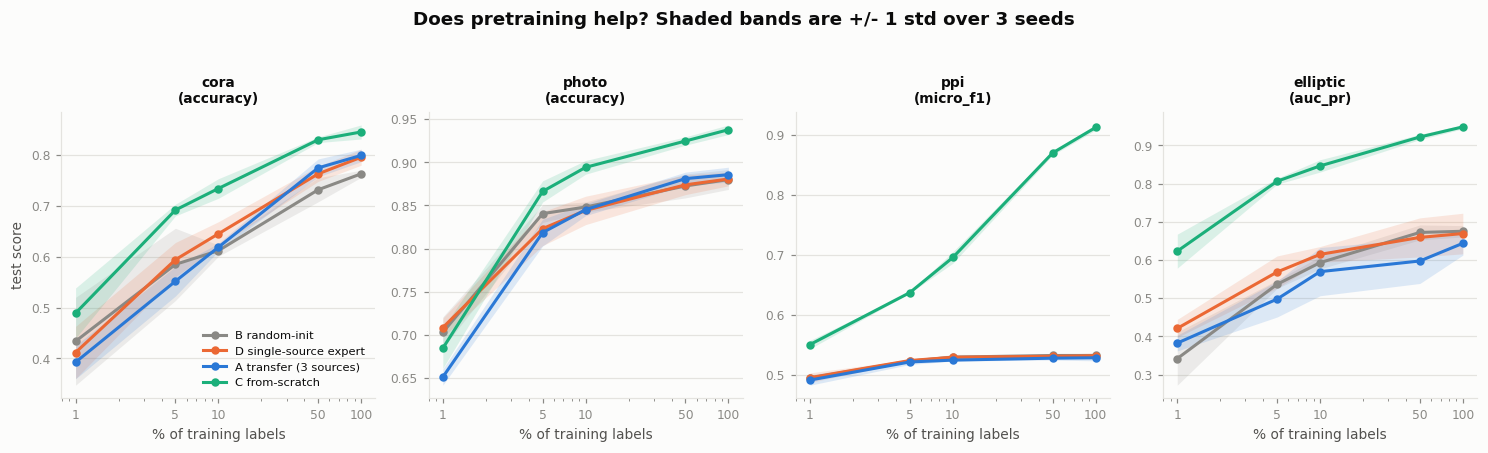

In [5]:
fig = plotting.plot_label_efficiency_by_arm(summary)

### What the curves show

The green line (arm C, from-scratch) sits clearly above everything else in
every panel. The other three - random init, single-source expert, multi-domain
transfer - are bundled together inside each other's error bands.

That bundling is the result. Three arms whose encoders were produced in
completely different ways land in the same place.

PPI is the starkest version: all three frozen arms sit flat between 0.49 and
0.53 **regardless of how many labels they get**, while from-scratch climbs to
0.91. A frozen representation that does not improve with more labels is one
that simply does not contain the information the task needs - and no amount of
labelled data lets a linear probe read what is not there.

## 2. Question one: does pretraining beat a random encoder?

Positive means the pretrained encoder won. Hatched cells are gaps smaller than
their own spread across seeds - not evidence in either direction.

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\06_gain_vs_random.png


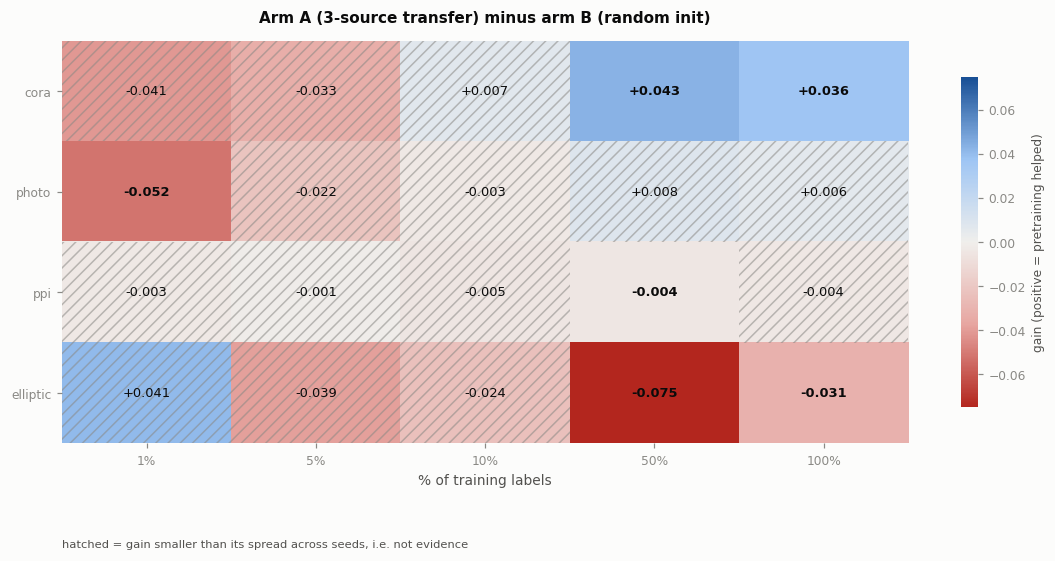

In [6]:
gains = results.transfer_gain(df)
fig = plotting.plot_gain_heatmap(
    gains, "gain_vs_random",
    title="Arm A (3-source transfer) minus arm B (random init)",
    save_as="06_gain_vs_random",
)

In [7]:
v_random = results.verdict(gains, "gain_vs_random")
counts = v_random["verdict"].value_counts().to_dict()
print("across the 20 (domain x label-fraction) cells:")
for k in ["positive", "indistinguishable", "negative"]:
    print(f"  {k:<20} {counts.get(k, 0):>2}")
print()
print(f"largest gain : {v_random['mean'].max():+.3f}")
print(f"largest loss : {v_random['mean'].min():+.3f}")
print(f"mean gain    : {v_random['mean'].mean():+.4f}")

across the 20 (domain x label-fraction) cells:
  positive              2
  indistinguishable    14
  negative              4

largest gain : +0.043
largest loss : -0.075
mean gain    : -0.0099


## 3. Question two: does multi-domain beat single-source?

This is the comparison arm D exists for, and it is the one that decides
whether "cross-domain" is doing any work in "cross-domain pretraining".

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\06_gain_vs_expert.png


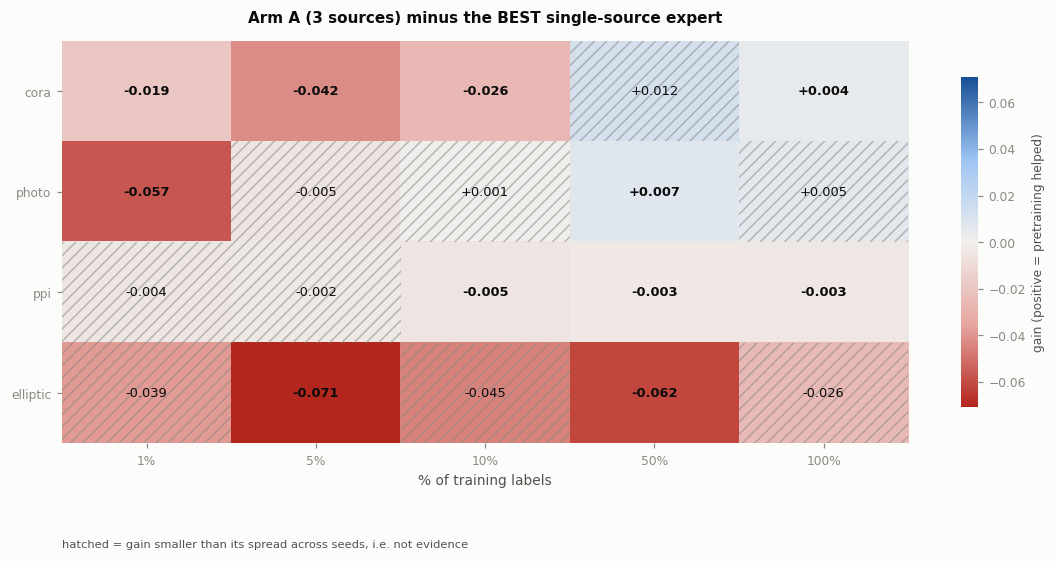

In [8]:
fig = plotting.plot_gain_heatmap(
    gains, "gain_vs_expert",
    title="Arm A (3 sources) minus the BEST single-source expert",
    save_as="06_gain_vs_expert",
)

In [9]:
v_expert = results.verdict(gains, "gain_vs_expert")
counts = v_expert["verdict"].value_counts().to_dict()
print("across the 20 (domain x label-fraction) cells:")
for k in ["positive", "indistinguishable", "negative"]:
    print(f"  {k:<20} {counts.get(k, 0):>2}")
print()
print(f"mean gain over the best expert: {v_expert['mean'].mean():+.4f}")
print()
print("Being fair in the other direction: 'best expert' is a maximum over")
print("three sources, which is optimistically biased -- taking the max of")
print("three noisy estimates inflates it. So here is arm A against the MEAN")
print("expert as well, which is biased the other way. The truth is between.")

experts = df[df["arm"] == "D_expert"].pivot_table(
    index=["target", "fraction", "seed"], columns="source_label", values="score")
a_arm = df[df["arm"] == "A_transfer"].set_index(["target", "fraction", "seed"])["score"]
mean_expert = experts.mean(axis=1)
paired = (a_arm - mean_expert).dropna()
print(f"\narm A minus MEAN expert, over all {len(paired)} paired runs: "
      f"{paired.mean():+.4f} ± {paired.std():.4f}")

across the 20 (domain x label-fraction) cells:
  positive              2
  indistinguishable     9
  negative              9

mean gain over the best expert: -0.0191

Being fair in the other direction: 'best expert' is a maximum over
three sources, which is optimistically biased -- taking the max of
three noisy estimates inflates it. So here is arm A against the MEAN
expert as well, which is biased the other way. The truth is between.

arm A minus MEAN expert, over all 60 paired runs: +0.0004 ± 0.0264


## 4. Which single source was best?

If cross-domain transfer worked through some general "graph-ness", the best
source would be roughly arbitrary. If it worked through similarity, the best
source would be the one most like the target. The counts below are per
(label fraction x seed), 15 per fold.

In [10]:
best = results.best_expert(df)
pivot = best.pivot_table(index="target", columns="source_label",
                         values="score", aggfunc="size").fillna(0).astype(int)
display(pivot)
print("Each row sums to 15 (5 label fractions x 3 seeds).")
print()
print("Elliptic is chosen most often as a source for both Photo and PPI, and")
print("it is the domain least like either of them -- sparsest, most skewed")
print("degree distribution, lowest clustering. Notebook 07 takes this up.")

source_label,cora,elliptic,photo,ppi
target,,,,
cora,0,4,9,2
elliptic,8,0,5,2
photo,4,9,0,2
ppi,3,10,2,0


Each row sums to 15 (5 label fractions x 3 seeds).

Elliptic is chosen most often as a source for both Photo and PPI, and
it is the domain least like either of them -- sparsest, most skewed
degree distribution, lowest clustering. Notebook 07 takes this up.


## 5. The ceiling nobody reached

Arm C trains the same architecture end to end on the target's own labels. It
is not a transfer method; it is what you get if you ignore transfer entirely.

In [11]:
gap = gains[["target", "fraction", "gap_to_scratch_mean", "gap_to_scratch_std"]].copy()
wide = gap.pivot(index="target", columns="fraction", values="gap_to_scratch_mean")
display(wide.round(3))
print("Arm C minus arm A. Positive everywhere means from-scratch wins everywhere.")
print()
print(f"smallest gap : {wide.min().min():+.3f}")
print(f"largest gap  : {wide.max().max():+.3f}")
print()
print("And recall the convergence check: most non-converged runs are arm C,")
print("so this ceiling is understated. The real gap is larger.")

fraction,0.01,0.05,0.10,0.50,1.00
target,,,,,
cora,0.097,0.140,0.116,0.055,0.046
elliptic,0.241,0.309,0.277,0.325,0.305
photo,0.033,0.048,0.049,0.044,0.052
ppi,0.059,0.116,0.171,0.342,0.384


Arm C minus arm A. Positive everywhere means from-scratch wins everywhere.

smallest gap : +0.033
largest gap  : +0.384

And recall the convergence check: most non-converged runs are arm C,
so this ceiling is understated. The real gap is larger.


## 6. The answer

Stated plainly, because a negative result reported vaguely is worse than no
result at all.

In [12]:
n_cells = len(v_expert)
pos_r = int((v_random["verdict"] == "positive").sum())
pos_e = int((v_expert["verdict"] == "positive").sum())
neg_e = int((v_expert["verdict"] == "negative").sum())

print("=" * 68)
print("Does a single GNN encoder, pretrained on several unrelated graph")
print("domains, transfer to a domain it has never seen?")
print("=" * 68)
print()
print(f"1. Better than a random-init encoder?")
print(f"   Beat it in {pos_r} of {n_cells} cells. Mean difference "
      f"{v_random['mean'].mean():+.4f}.")
print(f"   ANSWER: No. Mostly indistinguishable, and negative as often as")
print(f"   positive.")
print()
print(f"2. Better than pretraining on a SINGLE source domain?")
print(f"   Beat the best expert in {pos_e} of {n_cells} cells, lost in {neg_e}.")
print(f"   Mean difference {v_expert['mean'].mean():+.4f}.")
print(f"   ANSWER: No.")
print()
print(f"3. How far below simply training on the task?")
print(f"   Behind by {wide.min().min():.3f} to {wide.max().max():.3f} in every")
print(f"   single cell.")
print()
print("A random GIN with calibrated BatchNorm is as good an encoder as any")
print("pretrained one here. The message passing does the work; the")
print("pretraining does not.")
print("=" * 68)

Does a single GNN encoder, pretrained on several unrelated graph
domains, transfer to a domain it has never seen?

1. Better than a random-init encoder?
   Beat it in 2 of 20 cells. Mean difference -0.0099.
   ANSWER: No. Mostly indistinguishable, and negative as often as
   positive.

2. Better than pretraining on a SINGLE source domain?
   Beat the best expert in 2 of 20 cells, lost in 9.
   Mean difference -0.0191.
   ANSWER: No.

3. How far below simply training on the task?
   Behind by 0.033 to 0.384 in every
   single cell.

A random GIN with calibrated BatchNorm is as good an encoder as any
pretrained one here. The message passing does the work; the
pretraining does not.


## What you should now understand

- **The answer is no, on both counts.** A cross-domain pretrained encoder beat
  a random-init one in 2 of 20 cells, and beat the best single-source expert in
  2 of 20. In most cells the difference is smaller than the variation between
  seeds, which is not evidence of anything. Every frozen arm sits far below
  simply training the same architecture on the target's labels.
- **Arm D is what makes that statement possible.** On Cora at 100% labels, arm
  A beats random init by +0.036 - a clean positive that, reported alone, would
  read as "cross-domain transfer works". Against the best single-source expert
  the same cell is +0.004. Without arm D the project would have produced a
  finding it had not actually tested.
- **A negative result is a result.** Nothing here was tuned to change a sign.
  The four bugs fixed along the way were all found by asking "did this
  converge?" and "is this control fair?" - never by asking "how do I make this
  number bigger?"

**Next:** `07_analysis.ipynb` - if transfer gain is near zero everywhere,
can a domain-similarity measure predict what little there is?